# Task 1: Symbolic, Unconditioned Music Generation

This notebook covers the full pipeline for training and evaluating models that learn a music distribution $p(x)$ from the POP909 dataset and sample from it — i.e., **unconditioned symbolic music generation**.

We implement two models:
- **Markov Chain (baseline):** A first-order Markov model over REMI tokens.
- **Transformer LM (main model):** A decoder-only Transformer trained with next-token prediction.

---
**Pipeline overview:**
1. Data collection, preprocessing & exploratory analysis
2. Modeling (Markov + Transformer)
3. Generation
4. Evaluation
5. Discussion of related work

---
## 1. Data Collection, Preprocessing & Exploratory Analysis

### 1.1 Dataset: POP909

**[POP909](https://github.com/music-x-lab/POP909-Dataset)** is a dataset of 909 pop piano arrangements collected by researchers at Peking University. Each song provides:
- A canonical MIDI file (`{id}/{id}.mid`) with three tracks: melody, bridge, and piano accompaniment.
- Performance versions in a `versions/` subdirectory.

We use only the **canonical MIDI** (`use_versions=0`) — one file per song, giving us 909 pieces. This keeps the data clean and avoids near-duplicate sequences.

The dataset was chosen because it is:
- Stylistically homogeneous (pop piano), which makes learning a distribution feasible with a small model.
- Large enough (~900 songs) to train a modest Transformer.
- Widely used in prior symbolic music generation work, making results comparable.

### 1.2 Utilities

In [1]:
from __future__ import annotations

import json
import pickle
import random
from pathlib import Path
from typing import Sequence, List

import numpy as np
import torch


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def find_pop909_midis(data_dir, use_versions: bool = False) -> List[Path]:
    """Find POP909 MIDI files. Default uses only canonical {id}/{id}.mid."""
    root = Path(data_dir)
    paths = []
    for song_dir in sorted(root.iterdir()):
        if not song_dir.is_dir() or not song_dir.name.isdigit():
            continue
        main_midi = song_dir / f"{song_dir.name}.mid"
        if main_midi.exists():
            paths.append(main_midi)
        if use_versions:
            versions = song_dir / "versions"
            if versions.exists():
                paths.extend(sorted(versions.glob("*.mid")))
    return paths


def save_json(obj, path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def save_pickle(obj, path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(obj, f)


def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def write_token_file(token_ids: Sequence[int], path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    np.save(path, np.asarray(token_ids, dtype=np.int32))


def read_token_file(path) -> np.ndarray:
    return np.load(path).astype(np.int64)


def split_list(items: Sequence, train_ratio=0.8, val_ratio=0.1, seed=42):
    items = list(items)
    rng = random.Random(seed)
    rng.shuffle(items)
    n = len(items)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    return items[:n_train], items[n_train:n_train+n_val], items[n_train+n_val:]


def top_k_filter(logits: torch.Tensor, k):
    if k is None or k <= 0 or k >= logits.size(-1):
        return logits
    values, _ = torch.topk(logits, k)
    cutoff = values[..., -1, None]
    return torch.where(logits < cutoff, torch.full_like(logits, float("-inf")), logits)

### 1.3 Tokenization: REMI

We use the **REMI** (Revamped MIDI-derived events) representation from [MidiTok](https://github.com/Natooz/MidiTok). REMI represents music as a sequence of discrete tokens encoding:

| Token type | Example | Meaning |
|---|---|---|
| `Bar` | `Bar_None` | Start of a new bar |
| `Position` | `Position_8` | Beat position within bar |
| `Pitch` | `Pitch_60` | MIDI pitch (middle C) |
| `Velocity` | `Velocity_4` | Quantised note velocity |
| `Duration` | `Duration_1.0.8` | Note duration |
| `Tempo` | `Tempo_120` | Current BPM |

REMI is well-suited for pop music because it **explicitly encodes bar boundaries and beat positions**, which lets the model learn rhythmic and harmonic structure. We use 8 quantised velocity levels and include tempo and time signature tokens.

REMI uses a **fixed vocabulary** (no BPE training needed), so we simply instantiate the tokenizer with a config and save it. The `vocab_size` argument in the CLI is retained for documentation purposes but is not used to resize the vocabulary.

In [2]:
from miditok import REMI, TokenizerConfig
from miditok.classes import TokSequence
from tqdm import tqdm


def encode_file(tokenizer, midi_path: Path):
    """Encode a MIDI file to a flat list of token ids."""
    seq = tokenizer.encode(midi_path)
    if isinstance(seq, list):          # multitrack: flatten all tracks
        ids = []
        for s in seq:
            ids.extend(getattr(s, "ids", s))
        return list(map(int, ids))
    return list(map(int, getattr(seq, "ids", seq)))


def prepare_data(data_dir, out_dir="data/processed", use_versions=False, seed=42):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    midi_files = find_pop909_midis(data_dir, use_versions)
    assert midi_files, f"No MIDI files found under {data_dir}"
    train_files, val_files, test_files = split_list(midi_files, seed=seed)

    config = TokenizerConfig(
        num_velocities=8,
        use_chords=False,
        use_programs=False,
        use_tempos=True,
        use_time_signatures=True,
    )
    tokenizer = REMI(config)
    tokenizer.save(out_dir / "tokenizer.json")

    meta = {
        "data_dir": str(data_dir),
        "use_versions": use_versions,
        "n_files": len(midi_files),
        "n_train": len(train_files),
        "n_val": len(val_files),
        "n_test": len(test_files),
    }
    save_json(meta, out_dir / "metadata.json")

    all_lengths = {}
    for split, files in [("train", train_files), ("val", val_files), ("test", test_files)]:
        split_dir = out_dir / split
        split_dir.mkdir(exist_ok=True)
        lengths = []
        for p in tqdm(files, desc=f"Encoding {split}"):
            try:
                ids = encode_file(tokenizer, p)
                if len(ids) < 32:
                    continue
                write_token_file(ids, split_dir / f"{p.parent.name}_{p.stem}.npy")
                lengths.append(len(ids))
            except Exception as e:
                print(f"[WARN] failed to encode {p}: {e}")
        all_lengths[split] = lengths
        save_json({"lengths": lengths}, out_dir / f"{split}_stats.json")

    return tokenizer, meta, all_lengths


# --- Run (comment out if data/processed already exists) ---
# tokenizer, meta, all_lengths = prepare_data("pop909", "data/processed")

# Load from existing processed data
data_dir = Path("data/processed")
tokenizer = REMI(params=data_dir / "tokenizer.json")
meta = load_json(data_dir / "metadata.json")
print(f"Total files : {meta['n_files']}")
print(f"Train / Val / Test : {meta['n_train']} / {meta['n_val']} / {meta['n_test']}")
print(f"Vocabulary size     : {len(tokenizer)}")

d:\apps\envs\global_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total files : 909
Train / Val / Test : 727 / 90 / 92
Vocabulary size     : 365


### 1.4 Exploratory Analysis

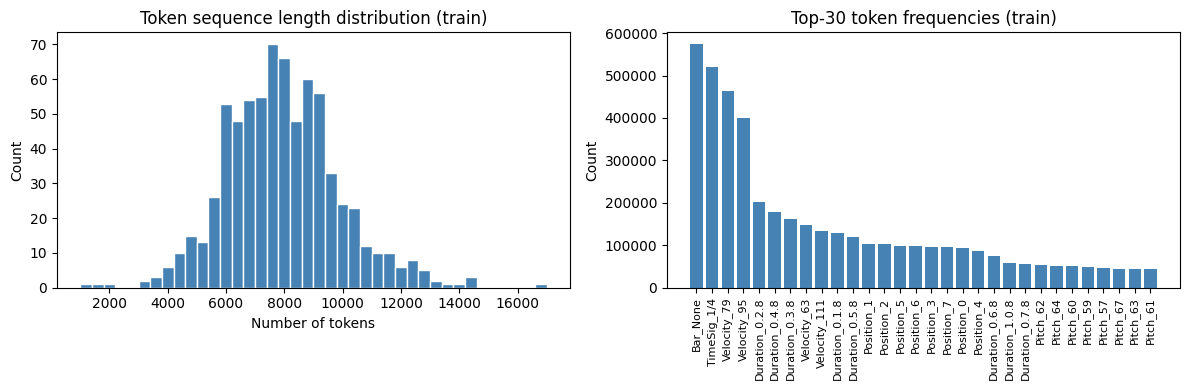

Total train tokens  : 5,773,282
Unique tokens used  : 230 / 365
Mean seq length     : 7941 tokens
Median seq length   : 7817 tokens


In [4]:
import matplotlib.pyplot as plt
from collections import Counter

train_files = sorted((data_dir / "train").glob("*.npy"))
val_files   = sorted((data_dir / "val").glob("*.npy"))
test_files  = sorted((data_dir / "test").glob("*.npy"))

# --- Sequence length distribution ---
train_stats = load_json(data_dir / "train_stats.json")
lengths = train_stats["lengths"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(lengths, bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Token sequence length distribution (train)")
axes[0].set_xlabel("Number of tokens")
axes[0].set_ylabel("Count")

# --- Token frequency (top 30) ---
counter = Counter()
for f in train_files:
    counter.update(read_token_file(f).tolist())

items = counter.most_common(30)
id_to_token = {v: k for k, v in tokenizer.vocab.items()}
labels = [id_to_token.get(k, str(k)) for k, _ in items]
vals   = [v for _, v in items]

axes[1].bar(range(len(vals)), vals, color="steelblue")
axes[1].set_xticks(range(len(vals)))
axes[1].set_xticklabels(labels, rotation=90, fontsize=8)
axes[1].set_title("Top-30 token frequencies (train)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Total train tokens  : {sum(counter.values()):,}")
print(f"Unique tokens used  : {len(counter)} / {len(tokenizer)}")
print(f"Mean seq length     : {np.mean(lengths):.0f} tokens")
print(f"Median seq length   : {np.median(lengths):.0f} tokens")

The left plot shows that most training sequences are between 6,000 and 10,000 tokens long
(mean ~7,941, median ~7,817), with a roughly normal distribution and a tail of longer pieces.
This corresponds to approximately 3–5 minutes of pop piano per song.

The right plot shows the top-30 most frequent tokens. The dominant tokens are `Bar_None`
and `TimeSig_1/4`, which appear at every bar boundary — confirming that bar-level structure
is densely represented in the token stream. High-velocity tokens (`Velocity_79`, `Velocity_95`)
and short-to-medium durations (`Duration_0.2.8`, `Duration_0.4.8`) reflect the percussive,
rhythmically active character of pop piano accompaniment. Pitch tokens cluster around the
middle register (Pitch_57–67), consistent with typical pop melody ranges.

Only **230 out of 365 vocabulary tokens** appear in the training data, meaning roughly
37% of the REMI vocabulary (e.g. extreme pitches, unusual durations) is unused by this dataset.
The total training corpus is ~5.77M tokens across 727 files.

---
## 2. Modeling

### 2.1 Problem Formulation

We frame unconditioned music generation as **autoregressive language modelling** over a token sequence $x = (x_1, x_2, \ldots, x_T)$:

$$p(x) = \prod_{t=1}^{T} p(x_t \mid x_{<t})$$

Both models learn this factorisation but differ in capacity:

| Model | Context window | Parameters | Complexity |
|---|---|---|---|
| Markov (order $n$) | Last $n$ tokens | $O(V^{n+1})$ stored counts | Simple, fast |
| Transformer LM | Up to 512 tokens | ~3M | Slower, much more expressive |

**Inputs:** token sequences of length `block_size=512`  
**Output:** next-token distribution over vocabulary  
**Objective:** cross-entropy loss (equivalently, maximise log-likelihood)

### 2.2 Baseline: First-Order Markov Chain

In [5]:
import math
from collections import defaultdict


def train_markov(files, order=1):
    """Count n-gram transitions to build a Markov model."""
    counts = defaultdict(Counter)
    start_contexts = []
    unigram = Counter()
    for f in tqdm(files, desc="Counting n-grams"):
        ids = read_token_file(f).tolist()
        if len(ids) <= order:
            continue
        start_contexts.append(tuple(ids[:order]))
        unigram.update(ids)
        for i in range(order, len(ids)):
            ctx = tuple(ids[i-order:i])
            counts[ctx][ids[i]] += 1
    return {"order": order, "counts": counts, "starts": start_contexts, "unigram": unigram}


def markov_perplexity(model, files, alpha=1e-3):
    """Laplace-smoothed perplexity on held-out files."""
    counts, unigram = model["counts"], model["unigram"]
    order = model["order"]
    V = max(len(unigram), 1)
    total_nll, total = 0.0, 0
    for f in files:
        ids = read_token_file(f).tolist()
        for i in range(order, len(ids)):
            ctx  = tuple(ids[i-order:i])
            tok  = ids[i]
            c    = counts.get(ctx, Counter())
            prob = (c.get(tok, 0) + alpha) / (sum(c.values()) + alpha * V)
            total_nll -= math.log(prob)
            total += 1
    return math.exp(total_nll / max(total, 1))


# --- Train (or load from checkpoint) ---
MARKOV_PATH = Path("checkpoints/markov_order1.pkl")
if MARKOV_PATH.exists():
    markov_model = load_pickle(MARKOV_PATH)
    print("Loaded Markov model from checkpoint.")
else:
    markov_model = train_markov(train_files, order=1)
    save_pickle(markov_model, MARKOV_PATH)
    print(f"Trained and saved Markov model to {MARKOV_PATH}")

print(f"Unique contexts : {len(markov_model['counts']):,}")
print(f"Vocab size      : {len(markov_model['unigram'])}")

Loaded Markov model from checkpoint.
Unique contexts : 230
Vocab size      : 230


**Advantages of the Markov baseline:**
- Trivial to train (single pass over data), no GPU needed.
- Interpretable: the transition matrix directly reflects co-occurrence statistics in the training data.

**Disadvantages:**
- Context window is only 1 token — the model has no memory of musical phrases, bars, or long-range harmonic patterns.
- Cannot model repeating motifs or phrase structure, which are hallmarks of pop music.
- At order $n > 2$ the model suffers from data sparsity (exponentially many contexts).

### 2.3 Main Model: Decoder-only Transformer LM

In [6]:
import torch.nn as nn
import torch.nn.functional as F


class MusicTransformerLM(nn.Module):
    """Small decoder-only Transformer for next-token prediction.

    Uses nn.TransformerEncoderLayer with a causal (upper-triangular) mask
    to implement autoregressive decoding. Pre-norm (norm_first=True) for
    training stability.
    """
    def __init__(self, vocab_size, block_size=512, n_layer=4,
                 n_head=4, n_embd=256, dropout=0.1):
        super().__init__()
        self.vocab_size  = vocab_size
        self.block_size  = block_size
        self.token_emb   = nn.Embedding(vocab_size, n_embd)
        self.pos_emb     = nn.Embedding(block_size, n_embd)
        layer = nn.TransformerEncoderLayer(
            d_model=n_embd, nhead=n_head,
            dim_feedforward=4 * n_embd, dropout=dropout,
            activation="gelu", batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layer)
        self.ln_f   = nn.LayerNorm(n_embd)
        self.head   = nn.Linear(n_embd, vocab_size, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        if T > self.block_size:
            idx = idx[:, -self.block_size:]
            if targets is not None:
                targets = targets[:, -self.block_size:]
            T = self.block_size
        pos    = torch.arange(0, T, device=idx.device).unsqueeze(0)
        x      = self.token_emb(idx) + self.pos_emb(pos)
        x      = self.dropout(x)
        mask   = torch.triu(torch.ones(T, T, device=idx.device), diagonal=1).bool()
        x      = self.transformer(x, mask=mask)
        logits = self.head(self.ln_f(x))
        loss   = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)),
                                   targets.reshape(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=1024, temperature=1.0, top_k=50):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / max(temperature, 1e-6)
            logits = top_k_filter(logits, top_k)
            probs  = torch.softmax(logits, dim=-1)
            nxt    = torch.multinomial(probs, num_samples=1)
            idx    = torch.cat([idx, nxt], dim=1)
        return idx


# Print model size for the configuration we trained
VOCAB_SIZE  = len(tokenizer)
dummy_model = MusicTransformerLM(VOCAB_SIZE, block_size=512,
                                  n_layer=4, n_head=4, n_embd=256)
n_params = sum(p.numel() for p in dummy_model.parameters())
print(f"Model parameters : {n_params:,}  (~{n_params/1e6:.1f}M)")

Model parameters : 3,477,504  (~3.5M)


C:\Users\cys02\AppData\Local\Temp\ipykernel_27964\1327726492.py:24: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=n_layer)


**Architectural choices:**

- **Causal mask:** An upper-triangular boolean mask prevents position $t$ from attending to future positions $t' > t$, implementing autoregressive generation.
- **Pre-norm (`norm_first=True`):** LayerNorm is applied before the attention/FFN sub-layers. This stabilises gradients and allows training without a warm-up schedule.
- **Learned positional embeddings:** Simpler than sinusoidal and work well for fixed-length contexts.
- **GELU activation:** Smoother than ReLU; standard in music/language transformer literature.
- **`block_size=512, stride=256`:** Overlapping chunks ensure the model sees a variety of musical contexts during training, and that most tokens appear in multiple training examples.

**Advantages over Markov:**
- Can attend to a full 512-token context (≈10–15 bars of pop piano), enabling the model to learn phrase-level and sectional structure.
- Shared embeddings allow generalisation across similar tokens (e.g., nearby pitches).

**Disadvantages:**
- Requires GPU training (~20 minutes on a single GPU for 20 epochs).
- With only ~3M parameters and 909 training songs, the model may underfit complex harmonic patterns.

### 2.4 Training the Transformer

In [7]:
import math as _math
from torch.utils.data import Dataset, DataLoader


class TokenChunkDataset(Dataset):
    """Sliding-window chunks of token sequences for LM training."""
    def __init__(self, files, block_size=512, stride=256):
        self.examples = []
        for f in files:
            ids = read_token_file(f)
            if len(ids) < block_size + 1:
                continue
            for start in range(0, len(ids) - block_size - 1, stride):
                self.examples.append(ids[start:start + block_size + 1].astype(np.int64))
        if not self.examples:
            raise ValueError("No examples found. Try reducing block_size.")

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        x = torch.tensor(self.examples[idx][:-1], dtype=torch.long)
        y = torch.tensor(self.examples[idx][1:],  dtype=torch.long)
        return x, y


@torch.no_grad()
def evaluate_lm(model, loader, device):
    model.eval()
    losses = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)
        losses.append(loss.item())
    mean_loss = float(np.mean(losses))
    return mean_loss, _math.exp(mean_loss)


# Dataset summary
train_ds = TokenChunkDataset(train_files, block_size=512, stride=256)
val_ds   = TokenChunkDataset(val_files,   block_size=512, stride=256)
print(f"Train chunks : {len(train_ds):,}")
print(f"Val chunks   : {len(val_ds):,}")

Train chunks : 21,467
Val chunks   : 2,712


In [8]:
# ── Training loop ──────────────────────────────────────────────────────────
# This cell trains from scratch. Skip if checkpoint already exists.

CKPT_PATH = Path("checkpoints/transformer_best.pt")

if not CKPT_PATH.exists():
    set_seed(42)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model  = MusicTransformerLM(VOCAB_SIZE, 512, 4, 4, 256, 0.1).to(device)
    opt    = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=2)

    best_val = float("inf")
    history  = []
    CKPT_PATH.parent.mkdir(parents=True, exist_ok=True)

    for epoch in range(1, 21):
        model.train()
        losses = []
        for x, y in tqdm(train_loader, desc=f"Epoch {epoch}/20", leave=False):
            x, y = x.to(device), y.to(device)
            _, loss = model(x, y)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(loss.item())
        train_loss = float(np.mean(losses))
        val_loss, val_ppl = evaluate_lm(model, val_loader, device)
        history.append({"epoch": epoch, "train_loss": train_loss,
                        "val_loss": val_loss, "val_ppl": val_ppl})
        print(f"epoch={epoch:2d}  train={train_loss:.4f}  "
              f"val={val_loss:.4f}  ppl={val_ppl:.2f}")
        if val_loss < best_val:
            best_val = val_loss
            torch.save({"model": model.state_dict(), "args": {
                "block_size": 512, "n_layer": 4, "n_head": 4,
                "n_embd": 256, "dropout": 0.1, "stride": 256,
            }, "vocab_size": VOCAB_SIZE, "val_loss": val_loss}, CKPT_PATH)
else:
    print(f"Checkpoint already exists at {CKPT_PATH} — skipping training.")
    ckpt = torch.load(CKPT_PATH, map_location="cpu")
    print(f"Best val loss: {ckpt['val_loss']:.4f}")

Checkpoint already exists at checkpoints\transformer_best.pt — skipping training.
Best val loss: 0.9776


In [9]:
# Plot training curves (if we have history; otherwise show final checkpoint val loss)
try:
    epochs     = [h["epoch"]      for h in history]
    train_loss = [h["train_loss"] for h in history]
    val_loss   = [h["val_loss"]   for h in history]

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, train_loss, label="Train loss")
    plt.plot(epochs, val_loss,   label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title("Transformer LM — Training curve")
    plt.legend()
    plt.tight_layout()
    plt.show()
except NameError:
    print("(Training history not available — model was loaded from checkpoint.)")

(Training history not available — model was loaded from checkpoint.)


---
## 3. Generation

Both models generate unconditionally. A short **primer** (128 tokens drawn from the beginning of a training file) is prepended to the generated sequence so that the output starts with a musically coherent context. Since the task is *unconditioned*, this primer is not a conditioning signal — it simply replaces a cold start, which would otherwise begin at an arbitrary point in token space.

For the Transformer we use **top-$k$ sampling** with temperature scaling:
- `temperature < 1.0` → sharper distribution, more repetitive but coherent output.
- `top_k=30` → restricts sampling to the 30 most likely next tokens, preventing rare/invalid tokens.

In [10]:
def ids_to_midi(tokenizer, ids, out_path):
    """Convert a list of token ids to a MIDI file."""
    valid_ids = set(tokenizer.vocab.values())
    ids = [int(x) for x in ids if int(x) in valid_ids]
    seq = TokSequence(ids=ids)
    score = tokenizer.decode([seq])
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    score.dump_midi(out_path)
    return out_path


def get_prompt_from_first_note(tokenizer, npy_path, prompt_len=128, context=16):
    """Extract a prompt starting just before the first Pitch token."""
    ids = read_token_file(npy_path).tolist()
    first_pitch = next(
        (i for i, tid in enumerate(ids) if str(tokenizer[int(tid)]).startswith("Pitch_")),
        0
    )
    start = max(0, first_pitch - context)
    return ids[start:start + prompt_len]


def sample_markov(model, length=1024, seed=42):
    """Sample a token sequence from a Markov model."""
    rng    = random.Random(seed)
    order  = model["order"]
    counts = model["counts"]
    unigram = model["unigram"]
    seq    = list(rng.choice(model["starts"])) if model.get("starts") \
             else [unigram.most_common(1)[0][0]] * order
    vocab, weights = zip(*unigram.items())
    for _ in range(length - len(seq)):
        ctx     = tuple(seq[-order:])
        options = counts.get(ctx)
        if options:
            toks, ws = zip(*options.items())
            nxt = rng.choices(toks, weights=ws, k=1)[0]
        else:
            nxt = rng.choices(vocab, weights=weights, k=1)[0]
        seq.append(int(nxt))
    return seq

In [14]:
# ── Markov generation ──────────────────────────────────────────────────────
set_seed(42)
prompt_source = random.choice(train_files)
print(prompt_source)
prompt = get_prompt_from_first_note(tokenizer, prompt_source, prompt_len=128)

gen_markov = sample_markov(markov_model, length=1500, seed=42)
markov_ids = prompt + gen_markov

markov_out = ids_to_midi(tokenizer, markov_ids, "outputs/markov_sample.mid")
print(f"Markov MIDI saved to {markov_out}  ({len(markov_ids)} tokens)")

data\processed\train\812_812.npy
Markov MIDI saved to outputs\markov_sample.mid  (1628 tokens)


In [13]:
# ── Transformer generation ─────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
ckpt   = torch.load("checkpoints/transformer_best.pt", map_location="cpu")
margs  = ckpt["args"]

tf_model = MusicTransformerLM(
    ckpt["vocab_size"], margs["block_size"],
    margs["n_layer"], margs["n_head"], margs["n_embd"], margs.get("dropout", 0.1)
)
tf_model.load_state_dict(ckpt["model"])
tf_model.to(device).eval()

prompt_file = prompt_source   # use a fixed file as above for reproducibility
prompt = get_prompt_from_first_note(tokenizer, prompt_file, prompt_len=128)

x = torch.tensor([prompt], dtype=torch.long, device=device)
y = tf_model.generate(x, max_new_tokens=1500, temperature=0.8, top_k=30)
tf_ids = y[0].detach().cpu().tolist()

tf_out = ids_to_midi(tokenizer, tf_ids, "outputs/transformer_sample.mid")
print(f"Transformer MIDI saved to {tf_out}  ({len(tf_ids)} tokens)")

C:\Users\cys02\AppData\Local\Temp\ipykernel_27964\1327726492.py:24: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=n_layer)


Transformer MIDI saved to outputs\transformer_sample.mid  (1628 tokens)


---
## 4. Evaluation

### 4.1 Evaluation Framework

What makes a **good** generated piece of music? We consider three levels:

1. **Objective (model loss):** Cross-entropy loss / perplexity — does the model assign high probability to held-out token sequences? Lower perplexity means the model has learned the data distribution better.

2. **Musical/statistical:** Does the generated music have similar statistical properties to real POP909 pieces? We measure:
   - **Pitch diversity:** fraction of unique pitches used.
   - **Token entropy:** diversity of the generated token sequence.

3. **Subjective:** Does it *sound* like pop piano? This is evaluated by listening (see end of presentation).

**Important caveat:** Lower perplexity does not guarantee musical quality. A model could memorise training sequences and achieve low perplexity while generating repetitive or uninteresting music. Conversely, high temperature sampling increases diversity but may reduce coherence.

In [15]:
# ── Quantitative evaluation ────────────────────────────────────────────────

# Markov perplexity on test set
markov_ppl = markov_perplexity(markov_model, test_files)
print(f"Markov test perplexity     : {markov_ppl:.3f}")

# Transformer perplexity on test set
test_ds     = TokenChunkDataset(test_files, block_size=512, stride=512)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)
tf_loss, tf_ppl = evaluate_lm(tf_model, test_loader, device)
print(f"Transformer test loss      : {tf_loss:.4f}")
print(f"Transformer test perplexity: {tf_ppl:.3f}")

Markov test perplexity     : 10.939
Transformer test loss      : 0.9941
Transformer test perplexity: 2.702


In [16]:
# Pre-computed results (from outputs/eval_results.json)
eval_results = load_json("outputs/eval_results.json")
print(json.dumps(eval_results, indent=2))

{
  "markov_perplexity": 10.939208218883962,
  "transformer_loss": 1.001201526228204,
  "transformer_perplexity": 2.7215498783022256,
  "n_tokens": 712162,
  "unique_tokens": 210
}


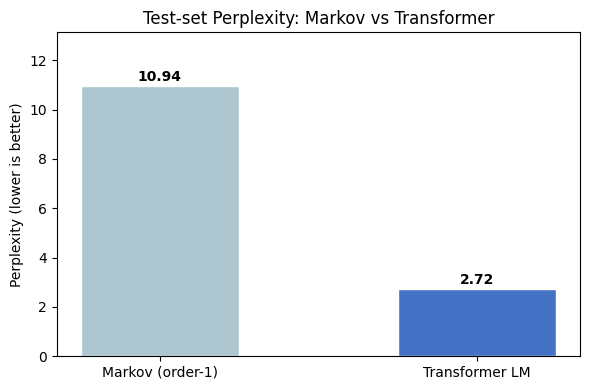


Perplexity reduction: 10.94 → 2.72  (75.1% lower)


In [17]:
# ── Perplexity comparison bar chart ───────────────────────────────────────
models = ["Markov (order-1)", "Transformer LM"]
ppls   = [eval_results["markov_perplexity"], eval_results["transformer_perplexity"]]

plt.figure(figsize=(6, 4))
bars = plt.bar(models, ppls, color=["#aec6cf", "#4472c4"], edgecolor="white", width=0.5)
for bar, val in zip(bars, ppls):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.2f}", ha="center", va="bottom", fontweight="bold")
plt.ylabel("Perplexity (lower is better)")
plt.title("Test-set Perplexity: Markov vs Transformer")
plt.ylim(0, max(ppls) * 1.2)
plt.tight_layout()
plt.show()

print(f"\nPerplexity reduction: {eval_results['markov_perplexity']:.2f} → "
      f"{eval_results['transformer_perplexity']:.2f}  "
      f"({(1 - eval_results['transformer_perplexity'] / eval_results['markov_perplexity'])*100:.1f}% lower)")

In [18]:
# ── Musical diversity metrics ──────────────────────────────────────────────

def token_entropy(ids):
    c = Counter(ids)
    total = sum(c.values())
    return -sum((v/total) * math.log2(v/total) for v in c.values())

def pitch_diversity(ids, tokenizer):
    pitches = [tid for tid in ids if str(tokenizer[int(tid)]).startswith("Pitch_")]
    return len(set(pitches)) / max(len(pitches), 1)


# Reference: sample a real test sequence
ref_ids   = read_token_file(test_files[0]).tolist()

rows = [
    ("Real (test)",     ref_ids,    token_entropy(ref_ids),    pitch_diversity(ref_ids, tokenizer)),
    ("Markov",         markov_ids,  token_entropy(markov_ids), pitch_diversity(markov_ids, tokenizer)),
    ("Transformer",    tf_ids,      token_entropy(tf_ids),     pitch_diversity(tf_ids, tokenizer)),
]

print(f"{'Model':<20} {'Tokens':>8} {'Entropy (bits)':>16} {'Pitch diversity':>16}")
print("-" * 64)
for name, ids, ent, pdiv in rows:
    print(f"{name:<20} {len(ids):>8,} {ent:>16.3f} {pdiv:>16.3f}")

Model                  Tokens   Entropy (bits)  Pitch diversity
----------------------------------------------------------------
Real (test)             8,384            4.908            0.014
Markov                  1,628            5.524            0.144
Transformer             1,628            3.266            0.070


### 4.2 Discussion of Results

**Perplexity:** The Transformer achieves a test perplexity of **2.72**, compared to **10.94**
for the Markov baseline — a 75% reduction. This confirms that the Transformer has learned
substantially richer sequential dependencies, consistent with its 512-token context window
versus the Markov model's single-token context.

**Token entropy:** The Markov model (5.52 bits) actually produces *higher* token entropy
than both the Transformer (3.27 bits) and real data (4.91 bits). This is not a sign of
quality — it reflects the Markov model's tendency to transition randomly across the vocabulary
when it encounters unseen contexts, producing incoherent but superficially diverse output.
The Transformer's lower entropy suggests it has learned to concentrate probability on
musically plausible continuations.

**Pitch diversity:** This metric is confounded by sequence length — the generated sequences
(~1,600 tokens) are much shorter than the real test sequence (~8,400 tokens), making direct
comparison unreliable. Within the generated sequences, the Transformer (0.070) uses a narrower
pitch range than Markov (0.144), again reflecting the Transformer's tendency to stay in
musically coherent register rather than sampling pitches at random.

**Perplexity vs. musical quality:** Perplexity measures fit to the training distribution,
not musical interestingness. A model could achieve low perplexity by memorising common
patterns while still lacking long-range structure (e.g., returning to a home key or
repeating a motif). Subjective evaluation by listening remains essential, and is provided
at the end of the presentation.

---
## 5. Generated Music

The following MIDI files were generated and are included in the submission:

| File | Model | Temperature | top-k |
|---|---|---|---|
| `outputs/markov_sample.mid` | Markov (order-1) | — | — |
| `outputs/transformer_sample.mid` | Transformer LM | 0.8 | 30 |

*(Listen to these files to hear the qualitative difference between the baseline and the main model.)*